# CSE440 Lab Project - Mental Health Statement Classification

Multi-class text classification over 7 mental-health status labels, plus a screening
chatbot wrapper.

Every trained model is written to `/kaggle/working/artifacts/` as soon as it wins its
architecture, so an interrupted session never loses work and the evaluation section
reloads from disk instead of from memory.

## 0. Environment setup

In [10]:
# --- Run this cell FIRST, before anything else imports numpy/scipy ---
# pip must not run after numpy/tensorflow are already imported: if it swaps a version,
# the modules already in memory are stale.
!pip install -q "gensim>=4.3.3"

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)
print("nltk corpora ready")

nltk corpora ready


In [11]:
import os, re, gc, json, time, string, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
import kagglehub

from gensim.models import Word2Vec

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score)

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Everything trained gets written here. /kaggle/working survives "Save & Run All"
# and is downloadable from the kernel Output tab.
ART = Path("/kaggle/working/artifacts")
ART.mkdir(parents=True, exist_ok=True)

RESUME   = True   # if an artifact already exists for a model, skip re-training it
RUN_BERT = True   # needs Internet ON, or bert-base-uncased attached as an input dataset

gpus = tf.config.list_physical_devices("GPU")
print("TF GPUs:", gpus if gpus else
      "NONE  <-- Settings > Accelerator > GPU. On CPU the RNN section takes hours.")
print("artifacts ->", ART)

TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
artifacts -> /kaggle/working/artifacts


### Carrying artifacts forward between versions

A committed run (**Save & Run All**) starts with an **empty** `/kaggle/working`. Without
this cell, a version that only finishes half the models would publish an output containing
only that half - the earlier weights would be gone.

Attaching the previous version's output as an input and copying it in first makes every
version **cumulative**: the newest version always holds the best weights for *all* models,
so "download the latest version" is always the complete set.

**One-time setup:** run the notebook once, save a version, then
**Add Input -> Notebook Output -> this notebook -> latest version**. From then on every
commit inherits everything before it.

In [12]:
from pathlib import Path
for p in sorted(Path("/kaggle/input").rglob("registry.json")):
    print(p)
for p in sorted(Path("/kaggle/input").glob("*")):
    print("top:", p)


/kaggle/input/notebooks/aritrosarkarkabyo/cse440-lab-project/artifacts/registry.json
top: /kaggle/input/datasets
top: /kaggle/input/notebooks


In [13]:
# Seed the working artifacts folder from the previous version's output (read-only input).
prev_dirs = [p.parent for p in Path("/kaggle/input").rglob("registry.json")]
prev_dirs = [p for p in prev_dirs if p.is_dir() and p != ART]


if prev_dirs:
    src = prev_dirs[-1]
    copied, skipped = 0, 0
    for p in src.rglob("*"):
        if p.is_file():
            dst = ART / p.relative_to(src)
            if dst.exists():
                skipped += 1
            else:
                dst.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(p, dst)
                copied += 1
    print(f"carried forward {copied} files from {src} ({skipped} already present)")
    if (ART / "registry.json").exists():
        print("inherited models:", list(json.loads((ART / "registry.json").read_text())))
else:
    print("No previous artifacts attached - this run starts fresh.")
    print("After it finishes: Save Version, then Add Input > Notebook Output > this notebook.")

carried forward 0 files from /kaggle/input/notebooks/aritrosarkarkabyo/cse440-lab-project/artifacts (26 already present)
inherited models: ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'SimpleRNN', 'Bidirectional SimpleRNN', 'GRU', 'Bidirectional GRU', 'LSTM', 'Bidirectional LSTM', 'BERT Base']


## 1. Data loading

In [14]:
CSV_CANDIDATES = [
    "/kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv",
    "/kaggle/input/sentiment-analysis-for-mental-health/Combined Data.csv",
]
csv_path = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)
if csv_path is None:                      # fall back to scanning whatever is mounted
    for dirname, _, filenames in os.walk("/kaggle/input"):
        for fn in filenames:
            if fn.lower().endswith(".csv") and "combined" in fn.lower():
                csv_path = os.path.join(dirname, fn)
print("data:", csv_path)

df = pd.read_csv(csv_path)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")   # errors="ignore" so a re-run is safe
display(df.head())

data: /kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


## 2. Exploratory data analysis

In [15]:
print(f"DATASET SHAPE: {df.shape}")
print(f"NUMBER OF CLASSES: {df['status'].nunique()}")

# Class distribution
print("CLASS DISTRIBUTION (status)")
print("=" * 40)
class_counts = df["status"].value_counts()
class_pct = df["status"].value_counts(normalize=True) * 100
class_summary = pd.DataFrame({"count": class_counts, "percentage": class_pct.round(2)})
display(class_summary)

# Missing values
print("\nMISSING VALUES")
print("=" * 40)
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_summary)

# Duplicates
print("\nDUPLICATES")
print("=" * 40)
print(f"Duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated 'statement' values: {df.duplicated(subset=['statement']).sum()}")

# Text length statistics (word count & character count)
df["char_len"] = df["statement"].astype(str).apply(len)
df["word_len"] = df["statement"].astype(str).apply(lambda x: len(x.split()))

print("\nTEXT LENGTH STATISTICS")
print("=" * 40)
display(df[["char_len", "word_len"]].describe())

DATASET SHAPE: (53043, 2)
NUMBER OF CLASSES: 7
CLASS DISTRIBUTION (status)


,count,percentage
status,,
Normal,16351,30.83
Depression,15404,29.04
Suicidal,10653,20.08
Anxiety,3888,7.33
Bipolar,2877,5.42
Stress,2669,5.03
Personality disorder,1201,2.26



MISSING VALUES


,missing_count,missing_pct
statement,362,0.68
status,0,0.00



DUPLICATES
Duplicated rows: 1944
Duplicated 'statement' values: 1969

TEXT LENGTH STATISTICS


,char_len,word_len
count,53043.000000,53043.000000
mean,574.784816,112.393285
std,844.707198,163.436684
min,2.000000,1.000000
25%,77.000000,15.000000
50%,313.000000,61.000000
75%,748.000000,147.500000
max,32759.000000,6300.000000


EDA VISUALIZATIONS


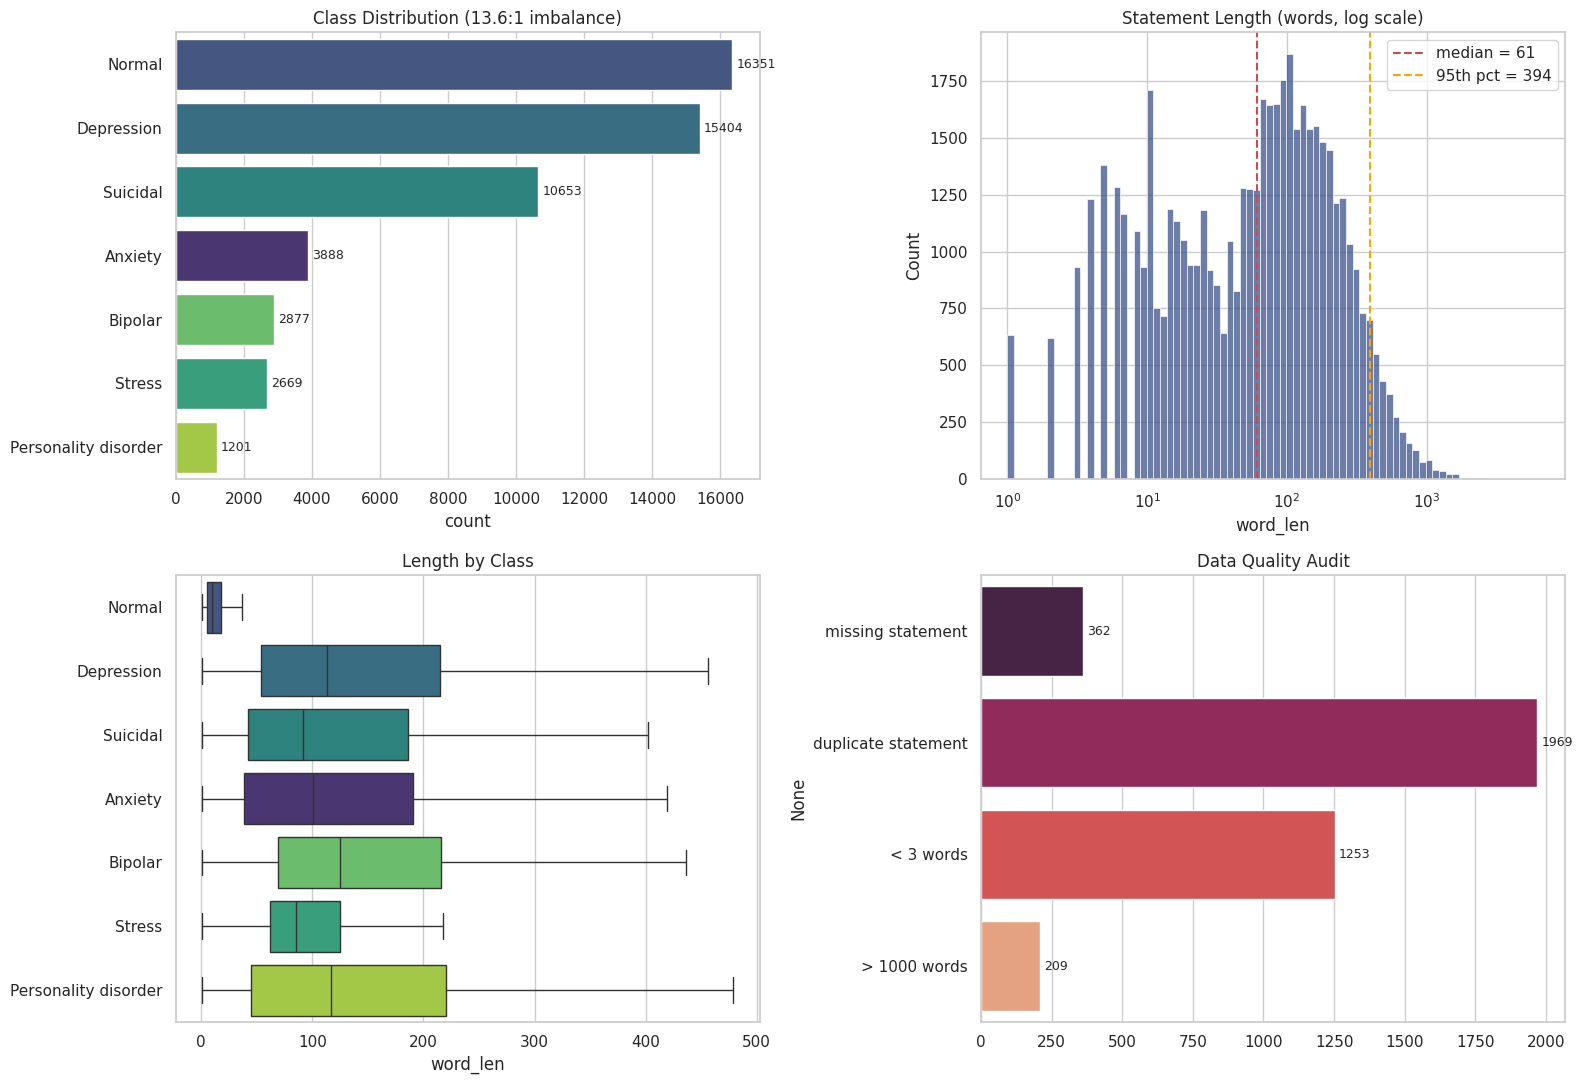

In [16]:
# EDA VISUALIZATIONS (on raw data, before preprocessing)
print("EDA VISUALIZATIONS")
print("=" * 40)

class_order = df["status"].value_counts().index    # renamed from `order`/`classes`:
                                                   # `classes` collided with the label array later

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Class distribution
sns.countplot(data=df, y="status", order=class_order, hue="status",
              palette="viridis", legend=False, ax=axes[0, 0])
for c in axes[0, 0].containers:
    axes[0, 0].bar_label(c, fmt="%d", padding=3, fontsize=9)
axes[0, 0].set_title("Class Distribution (13.6:1 imbalance)")
axes[0, 0].set_ylabel("")

# 2. Statement length distribution (log scale, heavy right tail)
sns.histplot(data=df, x="word_len", bins=80, log_scale=(True, False),
             color="#3b528b", ax=axes[0, 1])
axes[0, 1].axvline(df["word_len"].median(), ls="--", c="r",
                   label=f'median = {df["word_len"].median():.0f}')
axes[0, 1].axvline(df["word_len"].quantile(0.95), ls="--", c="orange",
                   label=f'95th pct = {df["word_len"].quantile(0.95):.0f}')
axes[0, 1].set_title("Statement Length (words, log scale)")
axes[0, 1].legend()

# 3. Length per class
sns.boxplot(data=df, x="word_len", y="status", order=class_order, hue="status",
            palette="viridis", legend=False, showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title("Length by Class")
axes[1, 0].set_ylabel("")

# 4. Data quality audit
audit = pd.Series({
    "missing statement": df["statement"].isna().sum(),
    "duplicate statement": df.duplicated(subset=["statement"]).sum(),
    "< 3 words": (df["word_len"] < 3).sum(),
    "> 1000 words": (df["word_len"] > 1000).sum(),
})
sns.barplot(x=audit.values, y=audit.index, hue=audit.index,
            palette="rocket", legend=False, ax=axes[1, 1])
for c in axes[1, 1].containers:
    axes[1, 1].bar_label(c, fmt="%d", padding=3, fontsize=9)
axes[1, 1].set_title("Data Quality Audit")

plt.tight_layout()
plt.show()

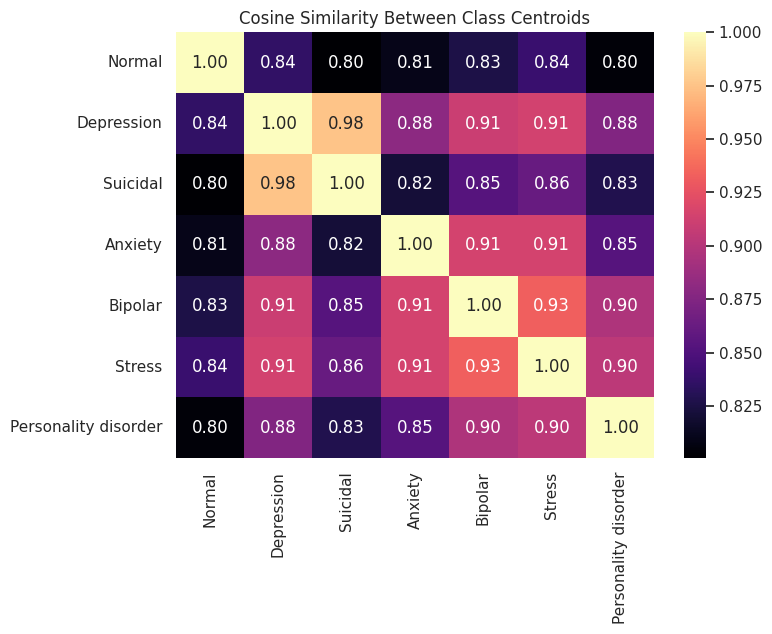

9769

In [17]:
# CLASS OVERLAP: cosine similarity between class centroids in TF-IDF space
from sklearn.metrics.pairwise import cosine_similarity

tmp_vec = TfidfVectorizer(max_features=10000, min_df=5)
tmp_X = tmp_vec.fit_transform(df["statement"].astype(str))

cls_list = list(class_order)
centroids = np.vstack([np.asarray(tmp_X[(df["status"] == c).values].mean(axis=0)).ravel()
                       for c in cls_list])

plt.figure(figsize=(8, 6.5))
sns.heatmap(cosine_similarity(centroids), annot=True, fmt=".2f",
            xticklabels=cls_list, yticklabels=cls_list, cmap="magma")
plt.title("Cosine Similarity Between Class Centroids")
plt.tight_layout()
plt.show()

del tmp_vec, tmp_X
gc.collect()

## 3. Preprocessing

In [18]:
# 1. Handle missing values
df = df.dropna(subset=["statement"]).reset_index(drop=True)
print(f"After dropping missing statements: {df.shape}")

# 2. Remove duplicates
df = df.drop_duplicates(subset=["statement"]).reset_index(drop=True)
print(f"After removing duplicate statements: {df.shape}")

After dropping missing statements: (52681, 4)
After removing duplicate statements: (51073, 4)


In [19]:
# 3. Preprocess text
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))
# Negations carry the signal here ("i can not sleep") - keep them
keep_words = {"no", "not", "nor", "never", "none", "cannot", "n't", "very", "too", "against"}
stop_words = stop_words - keep_words

url_re = re.compile(r"http\S+|www\.\S+")
user_re = re.compile(r"@\w+")
num_re = re.compile(r"\b\d+\b")
punct_table = str.maketrans("", "", string.punctuation)

def basic_clean(text):
    text = str(text).lower()
    text = url_re.sub(" ", text)
    text = user_re.sub(" ", text)
    text = text.translate(punct_table)
    text = num_re.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()

def preprocess(text, mode="lemma"):
    tokens = word_tokenize(basic_clean(text))
    filtered = []
    for token in tokens:
        if token not in stop_words and len(token) > 1:
            if mode == "lemma":
                filtered.append(lemmatizer.lemmatize(token, pos='v'))
            elif mode == "stem":
                filtered.append(stemmer.stem(token))
            else:
                filtered.append(token)
    return ' '.join(filtered)

# Three strategies to compare (Section 3.4)
df["prep_minimal"] = df["statement"].apply(basic_clean)
df["prep_lemma"]   = df["statement"].apply(lambda t: preprocess(t, "lemma"))
df["prep_stem"]    = df["statement"].apply(lambda t: preprocess(t, "stem"))

# 4. Drop rows that became empty after cleaning
before = len(df)
df = df[df["prep_lemma"].str.split().str.len() >= 2].reset_index(drop=True)
print(f"Dropped {before - len(df)} empty/near-empty rows: {df.shape}")

df["word_len"] = df["prep_lemma"].apply(lambda x: len(x.split()))
display(df[["statement", "prep_minimal", "prep_lemma", "prep_stem"]].head(3))

Dropped 978 empty/near-empty rows: (50095, 7)


,statement,prep_minimal,prep_lemma,prep_stem
0,oh my gosh,oh my gosh,oh gosh,oh gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,trouble sleep confuse mind restless heart tune,troubl sleep confus mind restless heart tune
2,"All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...,wrong back dear forward doubt stay restless re...,wrong back dear forward doubt stay restless re...


## 4. Train / validation / test split

In [20]:
y = df["status"].values
idx = np.arange(len(df))

# Split on INDICES once, then reuse for every representation (TF-IDF + sequences + BERT).
# Splitting twice in two cells gave the ML and NN models different test sets.
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, random_state=SEED, stratify=y)
idx_train, idx_val = train_test_split(
    idx_train, test_size=0.2, random_state=SEED, stratify=y[idx_train])

le = LabelEncoder().fit(y)
class_names = list(le.classes_)
NUM_CLASSES = len(class_names)

y_train = le.transform(y[idx_train])
y_val   = le.transform(y[idx_val])
y_test  = le.transform(y[idx_test])

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")
display(pd.DataFrame({
    "train": pd.Series(le.inverse_transform(y_train)).value_counts(normalize=True).round(3),
    "val":   pd.Series(le.inverse_transform(y_val)).value_counts(normalize=True).round(3),
    "test":  pd.Series(le.inverse_transform(y_test)).value_counts(normalize=True).round(3),
}))

# --- artifacts: the split and the label mapping must be reproducible at inference time
joblib.dump(le, ART / "label_encoder.joblib")
np.savez(ART / "splits.npz", idx_train=idx_train, idx_val=idx_val, idx_test=idx_test)

Train: 32060 | Val: 8016 | Test: 10019


,train,val,test
Normal,0.302,0.302,0.302
Depression,0.301,0.301,0.301
Suicidal,0.212,0.212,0.212
Anxiety,0.072,0.072,0.072
Bipolar,0.050,0.050,0.050
Stress,0.046,0.046,0.046
Personality disorder,0.018,0.018,0.018


In [21]:
# Section 3.4: which preprocessing strategy wins? Judge on VALIDATION with a fixed cheap model.
prep_results = []
for strat in ["prep_minimal", "prep_lemma", "prep_stem"]:
    vec = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
    Xtr = vec.fit_transform(df.loc[idx_train, strat].astype(str))
    Xva = vec.transform(df.loc[idx_val, strat].astype(str))
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
    clf.fit(Xtr, y_train)
    p = clf.predict(Xva)
    prep_results.append({
        "strategy": strat,
        "vocab_size": len(vec.vocabulary_),
        "val_accuracy": round(accuracy_score(y_val, p), 4),
        "val_macro_f1": round(f1_score(y_val, p, average='macro'), 4),
    })

prep_table = pd.DataFrame(prep_results).sort_values("val_macro_f1", ascending=False)
display(prep_table)
prep_table.to_csv(ART / "preprocessing_comparison.csv", index=False)

TEXT_COL = prep_table.iloc[0]["strategy"]
print(f"\nSelected preprocessing strategy: {TEXT_COL}")

,strategy,vocab_size,val_accuracy,val_macro_f1
0,prep_minimal,20000,0.7705,0.7307
1,prep_lemma,20000,0.7510,0.7052
2,prep_stem,20000,0.7505,0.7024



Selected preprocessing strategy: prep_minimal


## 5. Text representation

TF-IDF, then the Keras tokenizer, then the two embedding matrices. The tokenizer has to
be built **before** Word2Vec and GloVe, because `build_embedding_matrix` maps the
tokenizer's `word -> id` table onto the vectors. 

In [22]:
# Section 3.6 (A): TF-IDF
vectorizer = TfidfVectorizer(
    max_features=20000,   # 5000 was truncating minority-class vocabulary
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(df.loc[idx_train, TEXT_COL].astype(str))
X_val   = vectorizer.transform(df.loc[idx_val, TEXT_COL].astype(str))
X_test  = vectorizer.transform(df.loc[idx_test, TEXT_COL].astype(str))

print(f"TF-IDF: {X_train.shape} | {X_val.shape} | {X_test.shape}")

joblib.dump(vectorizer, ART / "tfidf_vectorizer.joblib")   # the chatbot needs this at inference

TF-IDF: (32060, 20000) | (8016, 20000) | (10019, 20000)


['/kaggle/working/artifacts/tfidf_vectorizer.joblib']

In [23]:
# Keras tokenizer -- MOVED UP from the Neural Networks section (see note above)
num_words = 20000

train_texts = df.loc[idx_train, TEXT_COL].astype(str).values
val_texts   = df.loc[idx_val,   TEXT_COL].astype(str).values
test_texts  = df.loc[idx_test,  TEXT_COL].astype(str).values

tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)   # fit on TRAIN only - fitting on all rows leaks test info

VOCAB_SIZE = min(num_words, len(tokenizer.word_index) + 1)
print("vocab:", VOCAB_SIZE)

(ART / "keras_tokenizer.json").write_text(tokenizer.to_json())

vocab: 20000


5924056

In [24]:
# Convert text to sequences using the mapping: 0 = PAD, 1 = OOV, 2+ = words
X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_val_seq   = tokenizer.texts_to_sequences(val_texts)
X_test_seq  = tokenizer.texts_to_sequences(test_texts)

# Cap at 200, not 300. Cost per epoch is linear in max_len, and a SimpleRNN over 300
# timesteps mostly vanishes its gradient - the first run scored macro-F1 0.26 that way.
MAX_LEN_CAP = 200
train_lens = np.array([len(t.split()) for t in train_texts])
pct95 = int(np.percentile(train_lens, 95))
max_len = min(pct95, MAX_LEN_CAP)
print(f"95th percentile = {pct95} -> max_len = {max_len} "
      f"({(train_lens > max_len).mean():.1%} of training docs get truncated)")

# padding="post" is required for the fast cuDNN LSTM/GRU kernels when mask_zero=True.
# "pre" silently falls back to the slow generic implementation.
X_train_seq = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_seq   = pad_sequences(X_val_seq,   maxlen=max_len, padding="post", truncating="post")
X_test_seq  = pad_sequences(X_test_seq,  maxlen=max_len, padding="post", truncating="post")

# One-hot labels (integer labels y_train/y_val/y_test already exist from the split cell)
y_train_oh = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_oh   = to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  num_classes=NUM_CLASSES)

95th percentile = 402 -> max_len = 200 (17.4% of training docs get truncated)


In [25]:
# Section 3.6 (B): Word2Vec trained on our own training split
EMB_DIM = 100

w2v_corpus = [t.split() for t in train_texts]
w2v = Word2Vec(sentences=w2v_corpus, vector_size=EMB_DIM, window=5,
               min_count=2, workers=4, sg=1, epochs=5, seed=SEED)   # sg=1 -> skip-gram
print("Word2Vec vocab:", len(w2v.wv))

def build_embedding_matrix(get_vector, dim):
    """Map our Keras tokenizer's word->id table onto pretrained vectors."""
    M = np.zeros((VOCAB_SIZE, dim), dtype="float32")   # row 0 stays zero = PAD
    hits = 0
    for word, i in tokenizer.word_index.items():
        if i >= VOCAB_SIZE:
            continue
        v = get_vector(word)
        if v is not None:
            M[i] = v
            hits += 1
    print(f"  coverage: {hits}/{VOCAB_SIZE-1} = {hits/(VOCAB_SIZE-1):.1%}")
    return M

print("Word2Vec matrix:")
W2V_MATRIX = build_embedding_matrix(lambda w: w2v.wv[w] if w in w2v.wv else None, EMB_DIM)

# Sanity check that it learned domain structure, not noise
for probe in ["sad", "anxious", "sleep", "panic"]:
    if probe in w2v.wv:
        print(f"  {probe:10s} ->", [w for w, _ in w2v.wv.most_similar(probe, topn=5)])

w2v.save(str(ART / "word2vec.model"))
np.save(ART / "emb_word2vec.npy", W2V_MATRIX)

Word2Vec vocab: 25040
Word2Vec matrix:
  coverage: 19998/19999 = 100.0%
  sad        -> ['depressed', 'lonely', 'heartbroken', 'conflicted', 'pessimistic']
  anxious    -> ['nervous', 'discouraged', 'conflicted', 'stressed', 'lethargic']
  sleep      -> ['nap', 'awake', 'sleeping', 'wake', '3am']
  panic      -> ['attack', 'attacks', 'panick', 'fullblown', 'mini']


In [26]:
# Section 3.6 (C): pre-trained GloVe (glove.6B.100d)
glove_path = None
for cand in ["/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt/glove.6B.100d.txt",
             "/kaggle/input/glove6b100dtxt/glove.6B.100d.txt",
             "/kaggle/input/glove6b/glove.6B.100d.txt"]:
    if os.path.exists(cand):
        glove_path = cand
        break

if glove_path is None:                      # needs Internet ON, or the dataset attached
    p = kagglehub.dataset_download("danielwillgeorge/glove6b100dtxt")
    for root, _, files in os.walk(p):
        for f in files:
            if f.endswith("100d.txt"):
                glove_path = os.path.join(root, f)
print("GloVe file:", glove_path)

glove_index = {}
with open(glove_path, encoding="utf8") as fh:
    for line in fh:
        parts = line.rstrip().split(" ")
        glove_index[parts[0]] = np.asarray(parts[1:], dtype="float32")
print("GloVe vectors loaded:", len(glove_index))

print("GloVe matrix:")
GLOVE_MATRIX = build_embedding_matrix(lambda w: glove_index.get(w), EMB_DIM)

np.save(ART / "emb_glove.npy", GLOVE_MATRIX)
del glove_index
gc.collect()

GloVe file: /kaggle/input/datasets/danielwillgeorge/glove6b100dtxt/glove.6B.100d.txt
GloVe vectors loaded: 400000
GloVe matrix:
  coverage: 17418/19999 = 87.1%


0

In [27]:
# Freeze the configuration the artifacts were built with, so inference can rebuild it exactly.
meta = {
    "TEXT_COL": TEXT_COL,
    "num_words": int(num_words),
    "VOCAB_SIZE": int(VOCAB_SIZE),
    "EMB_DIM": int(EMB_DIM),
    "max_len": int(max_len),
    "NUM_CLASSES": int(NUM_CLASSES),
    "class_names": [str(c) for c in class_names],
    "seed": SEED,
}
(ART / "meta.json").write_text(json.dumps(meta, indent=2))
print(json.dumps(meta, indent=2))

{
  "TEXT_COL": "prep_minimal",
  "num_words": 20000,
  "VOCAB_SIZE": 20000,
  "EMB_DIM": 100,
  "max_len": 200,
  "NUM_CLASSES": 7,
  "class_names": [
    "Anxiety",
    "Bipolar",
    "Depression",
    "Normal",
    "Personality disorder",
    "Stress",
    "Suicidal"
  ],
  "seed": 42
}


## 6. Tuning harness

`tuning_log`, `best_models` / `registry`, `log_run` and the class weights all used to live
*inside* the ML cell and the RNN cell, so the BERT section could not run without them.
They are shared infrastructure, so they get their own cell above every model section.

Two things make this crash-proof:

* `log_run` rewrites `hyperparameter_tuning_log.csv` after **every** configuration, so an
  interrupted session keeps all completed runs.
* `register_best` writes the winning model to disk and records it in `registry.json` the
  moment an architecture finishes. With `RESUME = True`, re-running the notebook skips
  anything already in the registry.

In [28]:
TUNING_CSV    = ART / "hyperparameter_tuning_log.csv"
REGISTRY_JSON = ART / "registry.json"
HISTORY_JSON  = ART / "nn_histories.json"

# Class weights: needed by BOTH the Keras models and the BERT loss, so they cannot live
# inside the RNN cell.
class_ids = np.unique(y_train)
class_weights_arr = compute_class_weight("balanced", classes=class_ids, y=y_train)
class_weight_dict = {int(k): float(v) for k, v in zip(class_ids, class_weights_arr)}
print("class weights:", {class_names[k]: round(v, 2) for k, v in class_weight_dict.items()})

def slug(name):
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")

tuning_log, registry, nn_histories = [], {}, {}
if RESUME and TUNING_CSV.exists():
    tuning_log = pd.read_csv(TUNING_CSV).to_dict("records")
if RESUME and REGISTRY_JSON.exists():
    registry = json.loads(REGISTRY_JSON.read_text())
if RESUME and HISTORY_JSON.exists():
    nn_histories = json.loads(HISTORY_JSON.read_text())
print(f"resumed: {len(tuning_log)} tuning rows | finished models: {list(registry) or 'none'}")


def log_run(name, config, y_true, y_pred, seconds, rep):
    row = {
        "model": name,
        "representation": rep,
        "config": str(config),
        "val_accuracy": round(accuracy_score(y_true, y_pred), 4),
        "val_macro_f1": round(f1_score(y_true, y_pred, average='macro'), 4),
        "val_weighted_f1": round(f1_score(y_true, y_pred, average='weighted'), 4),
        "train_seconds": round(seconds, 1),
    }
    tuning_log.append(row)
    pd.DataFrame(tuning_log).to_csv(TUNING_CSV, index=False)   # flush after every run
    print(f"  {name:24s} macroF1={row['val_macro_f1']:.4f}  acc={row['val_accuracy']:.4f}  "
          f"{str(config)[:52]}")
    return row


def register_best(name, row, kind, artifact, cfg=None):
    """Record the architecture winner. The weights are already on disk at `artifact`."""
    registry[name] = {
        "model": name,
        "kind": kind,                      # sklearn | keras | bert
        "artifact": str(artifact),
        "config": row["config"],
        "cfg": cfg,                        # structured config, needed to rebuild BERT loaders
        "val_accuracy": row["val_accuracy"],
        "val_macro_f1": row["val_macro_f1"],
        "train_seconds": row["train_seconds"],
    }
    REGISTRY_JSON.write_text(json.dumps(registry, indent=2))
    print(f"  BEST -> macroF1={row['val_macro_f1']:.4f}   saved: {artifact}")

class weights: {'Anxiety': 1.99, 'Bipolar': 2.86, 'Depression': 0.47, 'Normal': 0.47, 'Personality disorder': 7.99, 'Stress': 3.12, 'Suicidal': 0.67}
resumed: 31 tuning rows | finished models: ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'SimpleRNN', 'Bidirectional SimpleRNN', 'GRU', 'Bidirectional GRU', 'LSTM', 'Bidirectional LSTM', 'BERT Base']


## 7. Machine learning models (TF-IDF)

In [29]:
# Section 3.7 + 3.8: 3+ configs per model, selected on validation
model_configs = {
    'Logistic Regression': [
        (LogisticRegression, dict(C=0.5, max_iter=2000, class_weight='balanced', random_state=SEED)),
        (LogisticRegression, dict(C=1.0, max_iter=2000, class_weight='balanced', random_state=SEED)),
        (LogisticRegression, dict(C=5.0, max_iter=2000, class_weight=None,       random_state=SEED)),
    ],
    'Random Forest': [
        (RandomForestClassifier, dict(n_estimators=200, max_depth=None, min_samples_leaf=1,
                                      class_weight='balanced', n_jobs=-1, random_state=SEED)),
        (RandomForestClassifier, dict(n_estimators=400, max_depth=50, min_samples_leaf=2,
                                      class_weight='balanced_subsample', n_jobs=-1, random_state=SEED)),
        (RandomForestClassifier, dict(n_estimators=600, max_features='sqrt', min_samples_leaf=1,
                                      class_weight='balanced', n_jobs=-1, random_state=SEED)),
    ],
    'Naive Bayes': [
        (MultinomialNB, dict(alpha=0.2)),
        (MultinomialNB, dict(alpha=0.5)),
        (MultinomialNB, dict(alpha=1.0)),
        (ComplementNB,  dict(alpha=0.3)),   # variant built for imbalanced text
    ],
}

for name, configs in model_configs.items():
    if RESUME and name in registry:
        print(f"skip {name} (already in registry)")
        continue
    print("-" * 75)
    print(f"{name}:")
    best_row, best_est = None, None
    for cls, params in configs:
        t0 = time.time()
        model = cls(**params)
        model.fit(X_train, y_train)
        row = log_run(name, {"class": cls.__name__, **params},
                      y_val, model.predict(X_val), time.time() - t0, "TF-IDF")
        if best_row is None or row["val_macro_f1"] > best_row["val_macro_f1"]:
            best_row, best_est = row, model
    path = ART / f"{slug(name)}.joblib"
    joblib.dump(best_est, path, compress=3)   # RF is ~200 MB uncompressed
    register_best(name, best_row, "sklearn", path)
    del best_est
    gc.collect()

skip Logistic Regression (already in registry)
skip Random Forest (already in registry)
skip Naive Bayes (already in registry)


## 8. Recurrent neural networks

Each architecture's winning configuration is written to `<name>.keras` the instant it
becomes the winner, so `clear_session()` and `del model` are safe and the evaluation
section reads from disk rather than from six live models.

In [30]:
rnn_layers = {
    'SimpleRNN':               (SimpleRNN, False),
    'Bidirectional SimpleRNN': (SimpleRNN, True),
    'GRU':                     (GRU,       False),
    'Bidirectional GRU':       (GRU,       True),
    'LSTM':                    (LSTM,      False),
    'Bidirectional LSTM':      (LSTM,      True),
}

def build_rnn(layer_cls, bidir, units, dropout, emb_matrix, trainable_emb, lr):
    core = layer_cls(units)
    # Keras 3 removed the `weights=[...]` constructor kwarg on layers; the Constant
    # initializer is the portable way to seed an Embedding with a pretrained matrix.
    emb_init = (tf.keras.initializers.Constant(emb_matrix)
                if emb_matrix is not None else "uniform")
    model = Sequential([
        Input(shape=(max_len,), dtype="int32"),     # int32: avoids a cast on every batch
        Embedding(VOCAB_SIZE, EMB_DIM,
                  embeddings_initializer=emb_init,
                  trainable=trainable_emb, mask_zero=True),
        Bidirectional(core) if bidir else core,
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dropout(dropout),
        Dense(NUM_CLASSES, activation='softmax'),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Configs vary representation, capacity, regularisation and LR together
nn_configs = [
    dict(units=64,  dropout=0.3, emb='word2vec', trainable_emb=False, lr=1e-3, batch=64,  epochs=8),
    dict(units=128, dropout=0.5, emb='glove',    trainable_emb=True,  lr=1e-3, batch=64,  epochs=8),
    dict(units=64,  dropout=0.2, emb='glove',    trainable_emb=False, lr=5e-4, batch=128, epochs=8),
]
emb_matrices = {'word2vec': W2V_MATRIX, 'glove': GLOVE_MATRIX, 'random': None}

for name, (layer_cls, bidir) in rnn_layers.items():
    if RESUME and name in registry:
        print(f"skip {name} (already in registry)")
        continue
    print("-" * 75)
    print(f"{name}:")
    path = ART / f"{slug(name)}.keras"
    best_row = None
    for cfg in nn_configs:
        tf.keras.backend.clear_session()
        gc.collect()
        t0 = time.time()
        model = build_rnn(layer_cls, bidir, cfg['units'], cfg['dropout'],
                          emb_matrices[cfg['emb']], cfg['trainable_emb'], cfg['lr'])
        history = model.fit(
            X_train_seq, y_train_oh,
            epochs=cfg['epochs'],
            batch_size=cfg['batch'],
            validation_data=(X_val_seq, y_val_oh),
            class_weight=class_weight_dict,
            callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
            verbose=0,
        )
        y_pred = model.predict(X_val_seq, verbose=0).argmax(axis=1)
        row = log_run(name, cfg, y_val, y_pred, time.time() - t0, cfg['emb'])

        if best_row is None or row["val_macro_f1"] > best_row["val_macro_f1"]:
            best_row = row
            model.save(path)                          # weights hit disk immediately
            nn_histories[name] = {k: [float(x) for x in v] for k, v in history.history.items()}
            HISTORY_JSON.write_text(json.dumps(nn_histories, indent=2))
        del model, history
        gc.collect()

    register_best(name, best_row, "keras", path)

skip SimpleRNN (already in registry)
skip Bidirectional SimpleRNN (already in registry)
skip GRU (already in registry)
skip Bidirectional GRU (already in registry)
skip LSTM (already in registry)
skip Bidirectional LSTM (already in registry)


## 9. Transformer baseline (BERT)

The earlier run failed here with `Temporary failure in name resolution` - the kernel had
Internet off, so the checkpoint could not be downloaded. Turn on **Settings > Internet**,
or attach `bert-base-uncased` as an input and it will be picked up from `/kaggle/input`.
If neither is available the cell now reports it and the rest of the notebook still runs.

In [31]:
BERT_OK = False
if RUN_BERT:
    try:
        import torch
        from torch.utils.data import Dataset, DataLoader
        from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                                  get_linear_schedule_with_warmup)

        DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
        print("device:", DEVICE)
        if DEVICE == "cpu":
            print("  WARNING: fine-tuning BERT on CPU is not practical - enable the GPU.")

        # Prefer a locally attached checkpoint so the cell works with Internet off
        LOCAL_BERT = [p for p in ["/kaggle/input/bert-base-uncased",
                                  "/kaggle/input/huggingface-bert/bert-base-uncased"]
                      if os.path.isdir(p)]
        BERT_CKPT = LOCAL_BERT[0] if LOCAL_BERT else "bert-base-uncased"
        print("checkpoint:", BERT_CKPT)

        bert_tok = AutoTokenizer.from_pretrained(BERT_CKPT)
        BERT_OK = True
    except Exception as e:
        print("BERT unavailable:", type(e).__name__, str(e)[:200])
        print("Enable Internet in kernel settings, or attach bert-base-uncased as an input dataset.")

# BERT gets the LIGHTLY cleaned text: it has its own subword vocab and needs natural word
# forms. Feeding it stopword-stripped, lemmatised text throws away what it was pretrained on.
BERT_TEXT_COL = "prep_minimal"
BERT_DIR = ART / "bert_base"

if BERT_OK:
    class MHDataset(Dataset):
        def __init__(self, ix, labels, max_len):
            self.texts = df.loc[ix, BERT_TEXT_COL].astype(str).values
            self.labels = labels
            self.max_len = max_len
        def __len__(self):
            return len(self.labels)
        def __getitem__(self, i):
            enc = bert_tok(self.texts[i], truncation=True, padding="max_length",
                           max_length=self.max_len, return_tensors="pt")
            return {k: v.squeeze(0) for k, v in enc.items()} | {"labels": torch.tensor(self.labels[i])}

    def run_bert(cfg):
        torch.manual_seed(SEED)
        tr = DataLoader(MHDataset(idx_train, y_train, cfg["max_len"]),
                        batch_size=cfg["batch"], shuffle=True)
        va = DataLoader(MHDataset(idx_val, y_val, cfg["max_len"]),
                        batch_size=cfg["batch"] * 2)

        model = AutoModelForSequenceClassification.from_pretrained(
            BERT_CKPT, num_labels=NUM_CLASSES).to(DEVICE)

        opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"])
        steps = len(tr) * cfg["epochs"]
        sched = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
        lossf = torch.nn.CrossEntropyLoss(
            weight=torch.tensor(class_weights_arr, dtype=torch.float).to(DEVICE)
            if cfg.get("class_weighted") else None)

        for ep in range(cfg["epochs"]):
            model.train()
            for i, b in enumerate(tr):
                b = {k: v.to(DEVICE) for k, v in b.items()}
                labels = b.pop("labels")
                loss = lossf(model(**b).logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step(); opt.zero_grad()
                if i % 100 == 0:
                    print(f"    ep{ep} step{i}/{len(tr)} loss={loss.item():.4f}", end="\r")

        model.eval(); preds = []
        with torch.no_grad():
            for b in va:
                b = {k: v.to(DEVICE) for k, v in b.items()}; b.pop("labels")
                preds.append(model(**b).logits.argmax(1).cpu().numpy())
        return model, np.concatenate(preds)

    bert_configs = [
        dict(lr=2e-5, batch=16, epochs=2, max_len=128, class_weighted=True),
        dict(lr=3e-5, batch=32, epochs=2, max_len=192, class_weighted=True),
        dict(lr=5e-5, batch=32, epochs=1, max_len=128, class_weighted=False),
    ]

    if RESUME and "BERT Base" in registry:
        print("skip BERT Base (already in registry)")
    else:
        print("-" * 75)
        print("BERT Base:")
        best_row, best_cfg = None, None
        for cfg in bert_configs:
            t0 = time.time()
            m, pred = run_bert(cfg)
            row = log_run("BERT Base", cfg, y_val, pred, time.time() - t0, "WordPiece")
            if best_row is None or row["val_macro_f1"] > best_row["val_macro_f1"]:
                best_row, best_cfg = row, cfg
                m.save_pretrained(BERT_DIR)        # ~420 MB, written only for the winner
                bert_tok.save_pretrained(BERT_DIR)
            del m
            gc.collect()
            if DEVICE == "cuda":
                torch.cuda.empty_cache()
        register_best("BERT Base", best_row, "bert", BERT_DIR, cfg=best_cfg)

device: cuda
checkpoint: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

skip BERT Base (already in registry)


## 10. Hyperparameter tuning log

,model,representation,config,val_accuracy,val_macro_f1,val_weighted_f1,train_seconds
0,BERT Base,WordPiece,"{'lr': 3e-05, 'batch': 32, 'epochs': 2, 'max_l...",0.8149,0.7922,0.8164,2343.7
1,BERT Base,WordPiece,"{'lr': 2e-05, 'batch': 16, 'epochs': 2, 'max_l...",0.8104,0.7831,0.8113,1628.3
2,BERT Base,WordPiece,"{'lr': 5e-05, 'batch': 32, 'epochs': 1, 'max_l...",0.8190,0.7716,0.8183,791.7
3,Bidirectional GRU,word2vec,"{'units': 64, 'dropout': 0.3, 'emb': 'word2vec...",0.7638,0.7270,0.7648,75.4
4,Bidirectional GRU,glove,"{'units': 128, 'dropout': 0.5, 'emb': 'glove',...",0.7146,0.6846,0.7006,57.2
5,Bidirectional GRU,glove,"{'units': 64, 'dropout': 0.2, 'emb': 'glove', ...",0.7201,0.6531,0.7223,42.4
6,Bidirectional LSTM,glove,"{'units': 128, 'dropout': 0.5, 'emb': 'glove',...",0.7537,0.7189,0.7505,71.2
7,Bidirectional LSTM,word2vec,"{'units': 64, 'dropout': 0.3, 'emb': 'word2vec...",0.7536,0.7125,0.7577,76.9
8,Bidirectional LSTM,glove,"{'units': 64, 'dropout': 0.2, 'emb': 'glove', ...",0.6740,0.6112,0.6807,38.9
9,Bidirectional SimpleRNN,word2vec,"{'units': 64, 'dropout': 0.3, 'emb': 'word2vec...",0.5647,0.4436,0.5440,102.2


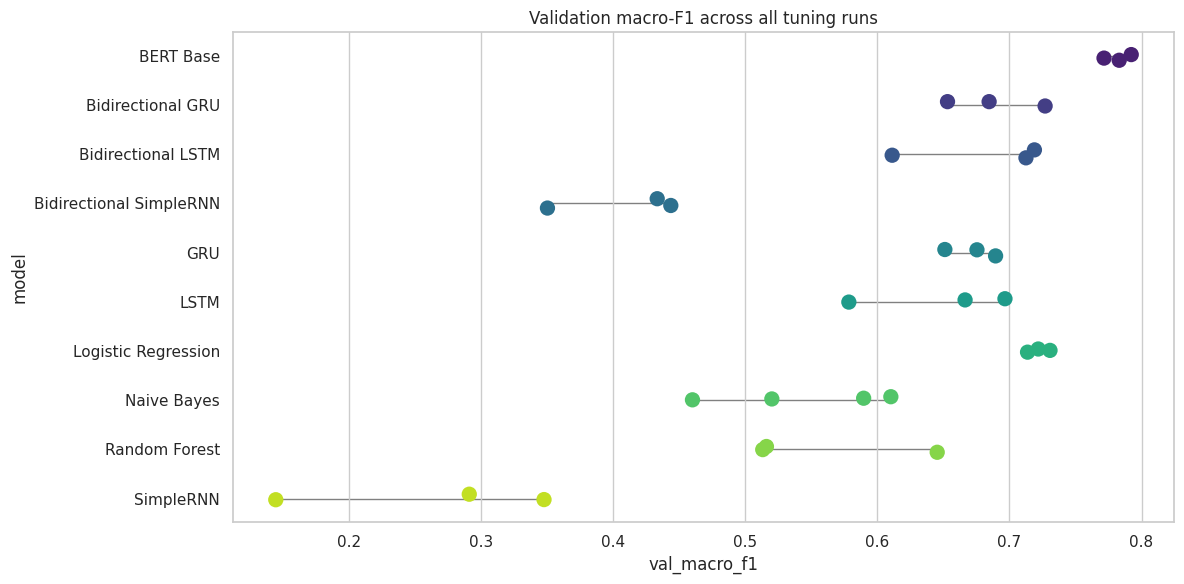

In [32]:
tuning_df = pd.DataFrame(tuning_log)
tuning_df = tuning_df.sort_values(["model", "val_macro_f1"],
                                  ascending=[True, False]).reset_index(drop=True)
display(tuning_df)
tuning_df.to_csv(TUNING_CSV, index=False)

# How sensitive is each model to its hyperparameters? (wide spread = fragile)
plt.figure(figsize=(12, 6))
sns.stripplot(data=tuning_df, x="val_macro_f1", y="model", hue="model",
              palette="viridis", size=11, legend=False)
for m, g in tuning_df.groupby("model"):
    plt.plot([g["val_macro_f1"].min(), g["val_macro_f1"].max()], [m, m],
             color="gray", lw=1, zorder=0)
plt.title("Validation macro-F1 across all tuning runs")
plt.tight_layout()
plt.show()

In [33]:
# What is actually saved on disk
rows = []
for p in sorted(ART.rglob("*")):
    if p.is_file():
        rows.append({"artifact": str(p.relative_to(ART)), "MB": round(p.stat().st_size / 1e6, 2)})
saved = pd.DataFrame(rows)
print(f"{len(saved)} files, {saved['MB'].sum():.1f} MB total in {ART}")
display(saved.sort_values("MB", ascending=False).head(20))

print("\nRegistered models:")
display(pd.DataFrame(registry).T[["kind", "val_macro_f1", "artifact"]])

26 files, 918.4 MB total in /kaggle/working/artifacts


,artifact,MB
1,bert_base/model.safetensors,437.97
20,random_forest.joblib,103.27
5,bidirectional_lstm.keras,64.88
15,lstm.keras,63.36
4,bidirectional_gru.keras,51.96
10,gru.keras,51.52
6,bidirectional_simplernn.keras,51.45
22,simplernn.keras,46.03
25,word2vec.model,20.89
8,emb_word2vec.npy,8.00



Registered models:


,kind,val_macro_f1,artifact
Logistic Regression,sklearn,0.7307,/kaggle/working/artifacts/logistic_regression....
Random Forest,sklearn,0.6453,/kaggle/working/artifacts/random_forest.joblib
Naive Bayes,sklearn,0.6102,/kaggle/working/artifacts/naive_bayes.joblib
SimpleRNN,keras,0.3476,/kaggle/working/artifacts/simplernn.keras
Bidirectional SimpleRNN,keras,0.4436,/kaggle/working/artifacts/bidirectional_simple...
GRU,keras,0.6895,/kaggle/working/artifacts/gru.keras
Bidirectional GRU,keras,0.727,/kaggle/working/artifacts/bidirectional_gru.keras
LSTM,keras,0.6966,/kaggle/working/artifacts/lstm.keras
Bidirectional LSTM,keras,0.7189,/kaggle/working/artifacts/bidirectional_lstm.k...
BERT Base,bert,0.7922,/kaggle/working/artifacts/bert_base


## 11. Final evaluation on the held-out test set

Every model is **loaded back from its artifact** here. This is the point of saving: the
numbers in the report come from the exact files you can hand in, and this section can be
re-run on a fresh kernel without retraining anything.

In [34]:
def load_and_predict(name, entry):
    kind = entry["kind"]
    if kind == "sklearn":
        return joblib.load(entry["artifact"]).predict(X_test)

    if kind == "keras":
        m = tf.keras.models.load_model(entry["artifact"])
        p = m.predict(X_test_seq, verbose=0).argmax(axis=1)
        del m
        tf.keras.backend.clear_session()
        gc.collect()
        return p

    if kind == "bert":
        m = AutoModelForSequenceClassification.from_pretrained(entry["artifact"]).to(DEVICE)
        m.eval()
        cfg = entry["cfg"]
        dl = DataLoader(MHDataset(idx_test, y_test, cfg["max_len"]), batch_size=cfg["batch"] * 2)
        out = []
        with torch.no_grad():
            for b in dl:
                b = {k: v.to(DEVICE) for k, v in b.items()}; b.pop("labels")
                out.append(m(**b).logits.argmax(1).cpu().numpy())
        del m
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        return np.concatenate(out)

    raise ValueError(f"unknown artifact kind: {kind}")


final_rows, test_preds = [], {}
for name, entry in registry.items():
    print("predicting:", name)
    pred = load_and_predict(name, entry)
    test_preds[name] = pred
    final_rows.append({
        "Model": name,
        "Best config": entry["config"],
        "Test Accuracy": round(accuracy_score(y_test, pred), 4),
        "Test Macro F1": round(f1_score(y_test, pred, average='macro'), 4),
        "Test Weighted F1": round(f1_score(y_test, pred, average='weighted'), 4),
        "Val Macro F1": entry["val_macro_f1"],
        "Train seconds": entry["train_seconds"],
    })

final_df = pd.DataFrame(final_rows).sort_values("Test Macro F1", ascending=False).reset_index(drop=True)
display(final_df)
final_df.to_csv(ART / "final_model_comparison.csv", index=False)

best_name  = final_df.iloc[0]["Model"]
worst_name = final_df.iloc[-1]["Model"]
print(f"\nBEST : {best_name}  (macro-F1 = {final_df.iloc[0]['Test Macro F1']})")
print(f"WORST: {worst_name} (macro-F1 = {final_df.iloc[-1]['Test Macro F1']})")

predicting: Logistic Regression
predicting: Random Forest
predicting: Naive Bayes
predicting: SimpleRNN


I0000 00:00:1787798927.441570      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787798927.444625      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1787798929.999891     169 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


predicting: Bidirectional SimpleRNN
predicting: GRU
predicting: Bidirectional GRU
predicting: LSTM
predicting: Bidirectional LSTM
predicting: BERT Base


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,Model,Best config,Test Accuracy,Test Macro F1,Test Weighted F1,Val Macro F1,Train seconds
0,BERT Base,"{'lr': 3e-05, 'batch': 32, 'epochs': 2, 'max_l...",0.8058,0.7796,0.8074,0.7922,2343.7
1,Bidirectional GRU,"{'units': 64, 'dropout': 0.3, 'emb': 'word2vec...",0.7619,0.7238,0.7637,0.7270,75.4
2,Logistic Regression,"{'class': 'LogisticRegression', 'C': 1.0, 'max...",0.7652,0.7136,0.7657,0.7307,14.6
3,Bidirectional LSTM,"{'units': 128, 'dropout': 0.5, 'emb': 'glove',...",0.7437,0.7086,0.7409,0.7189,71.2
4,LSTM,"{'units': 128, 'dropout': 0.5, 'emb': 'glove',...",0.7454,0.6979,0.7421,0.6966,51.0
5,GRU,"{'units': 64, 'dropout': 0.3, 'emb': 'word2vec...",0.7265,0.6862,0.7229,0.6895,52.1
6,Random Forest,"{'class': 'RandomForestClassifier', 'n_estimat...",0.7088,0.6383,0.7026,0.6453,78.0
7,Naive Bayes,"{'class': 'ComplementNB', 'alpha': 0.3}",0.6980,0.6110,0.6913,0.6102,0.0
8,Bidirectional SimpleRNN,"{'units': 64, 'dropout': 0.3, 'emb': 'word2vec...",0.5560,0.4353,0.5363,0.4436,102.2
9,SimpleRNN,"{'units': 64, 'dropout': 0.2, 'emb': 'glove', ...",0.4838,0.3324,0.4780,0.3476,43.1



BEST : BERT Base  (macro-F1 = 0.7796)
WORST: SimpleRNN (macro-F1 = 0.3324)


In [35]:
for name in final_df["Model"]:
    print("=" * 78)
    print(name)
    print("=" * 78)
    print(classification_report(y_test, test_preds[name], target_names=class_names,
                                digits=4, zero_division=0))

BERT Base
                      precision    recall  f1-score   support

             Anxiety     0.8367    0.8738    0.8548       721
             Bipolar     0.7780    0.8480    0.8115       500
          Depression     0.8306    0.6625    0.7371      3013
              Normal     0.9642    0.9172    0.9401      3021
Personality disorder     0.6599    0.7263    0.6915       179
              Stress     0.5949    0.8061    0.6846       459
            Suicidal     0.6674    0.8241    0.7375      2126

            accuracy                         0.8058     10019
           macro avg     0.7617    0.8083    0.7796     10019
        weighted avg     0.8202    0.8058    0.8074     10019

Bidirectional GRU
                      precision    recall  f1-score   support

             Anxiety     0.7719    0.8447    0.8066       721
             Bipolar     0.8308    0.7560    0.7916       500
          Depression     0.8547    0.5602    0.6768      3013
              Normal     0.9304    0.8

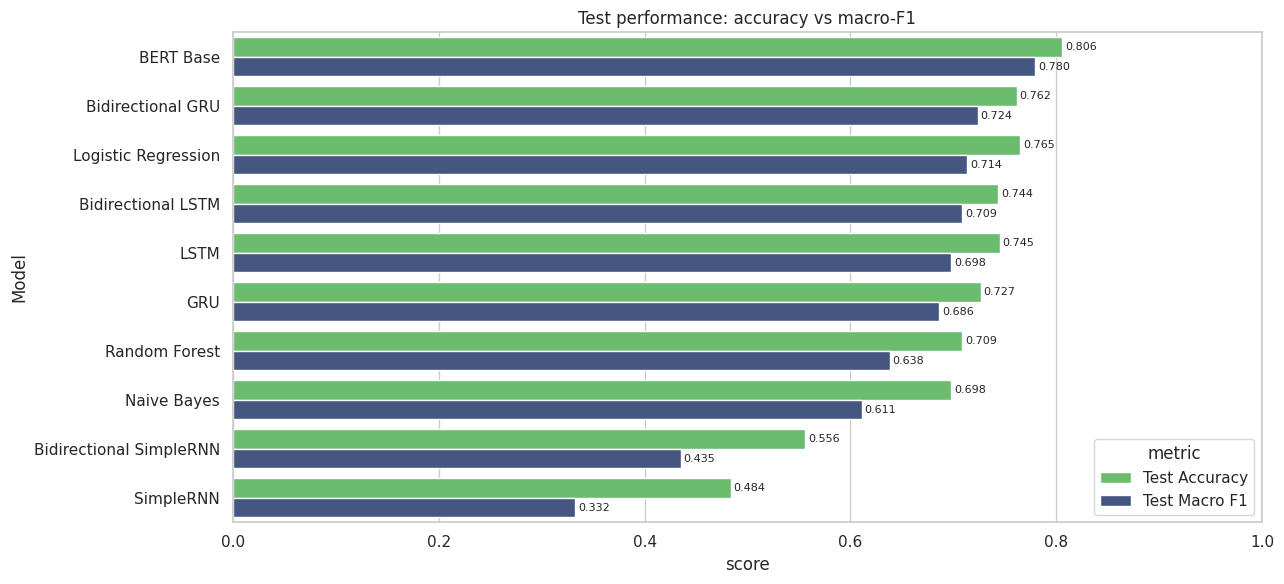

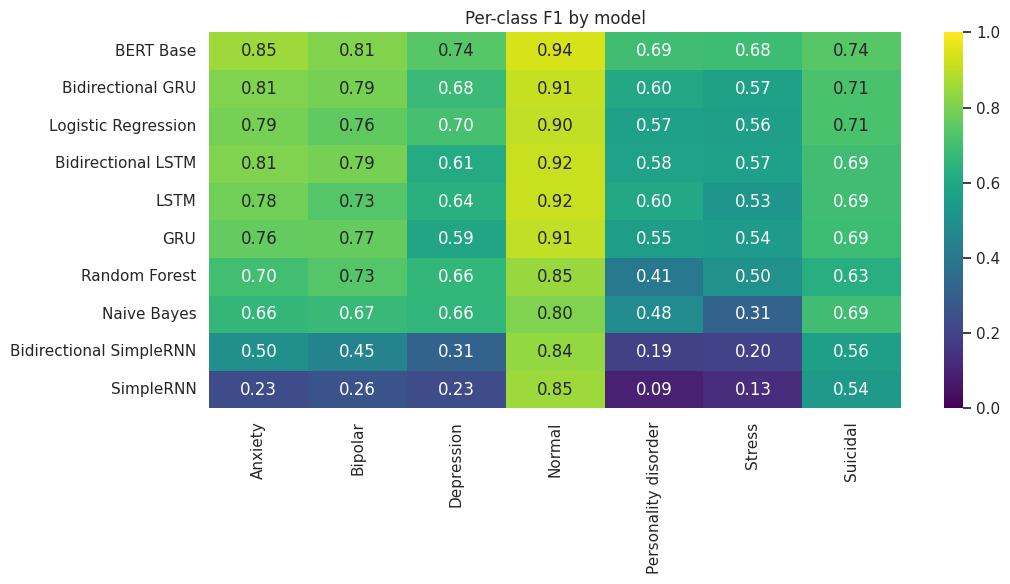

In [36]:
# Accuracy vs macro-F1: the gap IS the imbalance sensitivity
plot_df = final_df.melt(id_vars="Model", value_vars=["Test Accuracy", "Test Macro F1"],
                        var_name="metric", value_name="score")
plt.figure(figsize=(13, 6))
ax = sns.barplot(data=plot_df, x="score", y="Model", hue="metric", palette=["#5ec962", "#3b528b"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=2, fontsize=8)
plt.title("Test performance: accuracy vs macro-F1")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Per-class F1: shows exactly which classes each model fails on
per_class = pd.DataFrame(
    {name: f1_score(y_test, p, average=None, labels=range(NUM_CLASSES), zero_division=0)
     for name, p in test_preds.items()},
    index=class_names,
).T.loc[final_df["Model"]]

plt.figure(figsize=(11, 6))
sns.heatmap(per_class, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Per-class F1 by model")
plt.tight_layout()
plt.show()

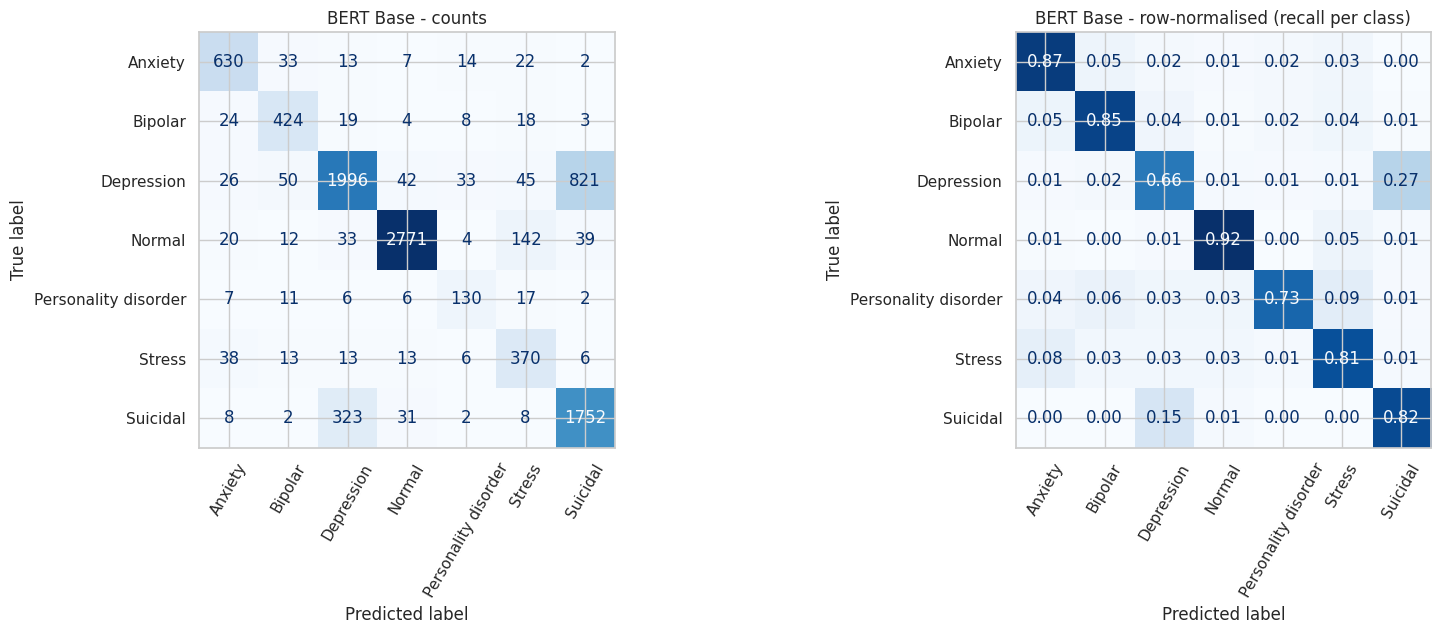

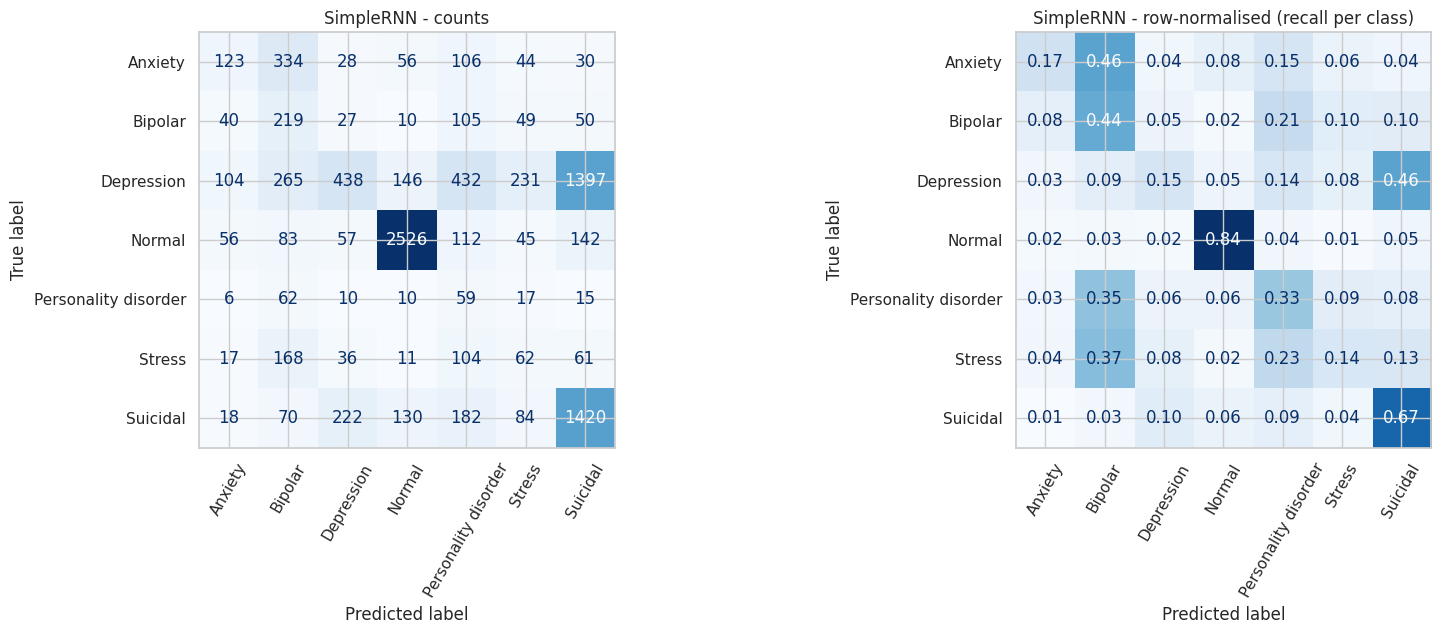

In [37]:
# Confusion matrices for best and worst
for name in [best_name, worst_name]:
    cm = confusion_matrix(y_test, test_preds[name])
    fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        cmap='Blues', xticks_rotation=60, ax=axes[0], colorbar=False, values_format='d')
    axes[0].set_title(f"{name} - counts")
    ConfusionMatrixDisplay(cm / cm.sum(1, keepdims=True), display_labels=class_names).plot(
        cmap='Blues', xticks_rotation=60, ax=axes[1], colorbar=False, values_format='.2f')
    axes[1].set_title(f"{name} - row-normalised (recall per class)")
    plt.tight_layout()
    plt.show()

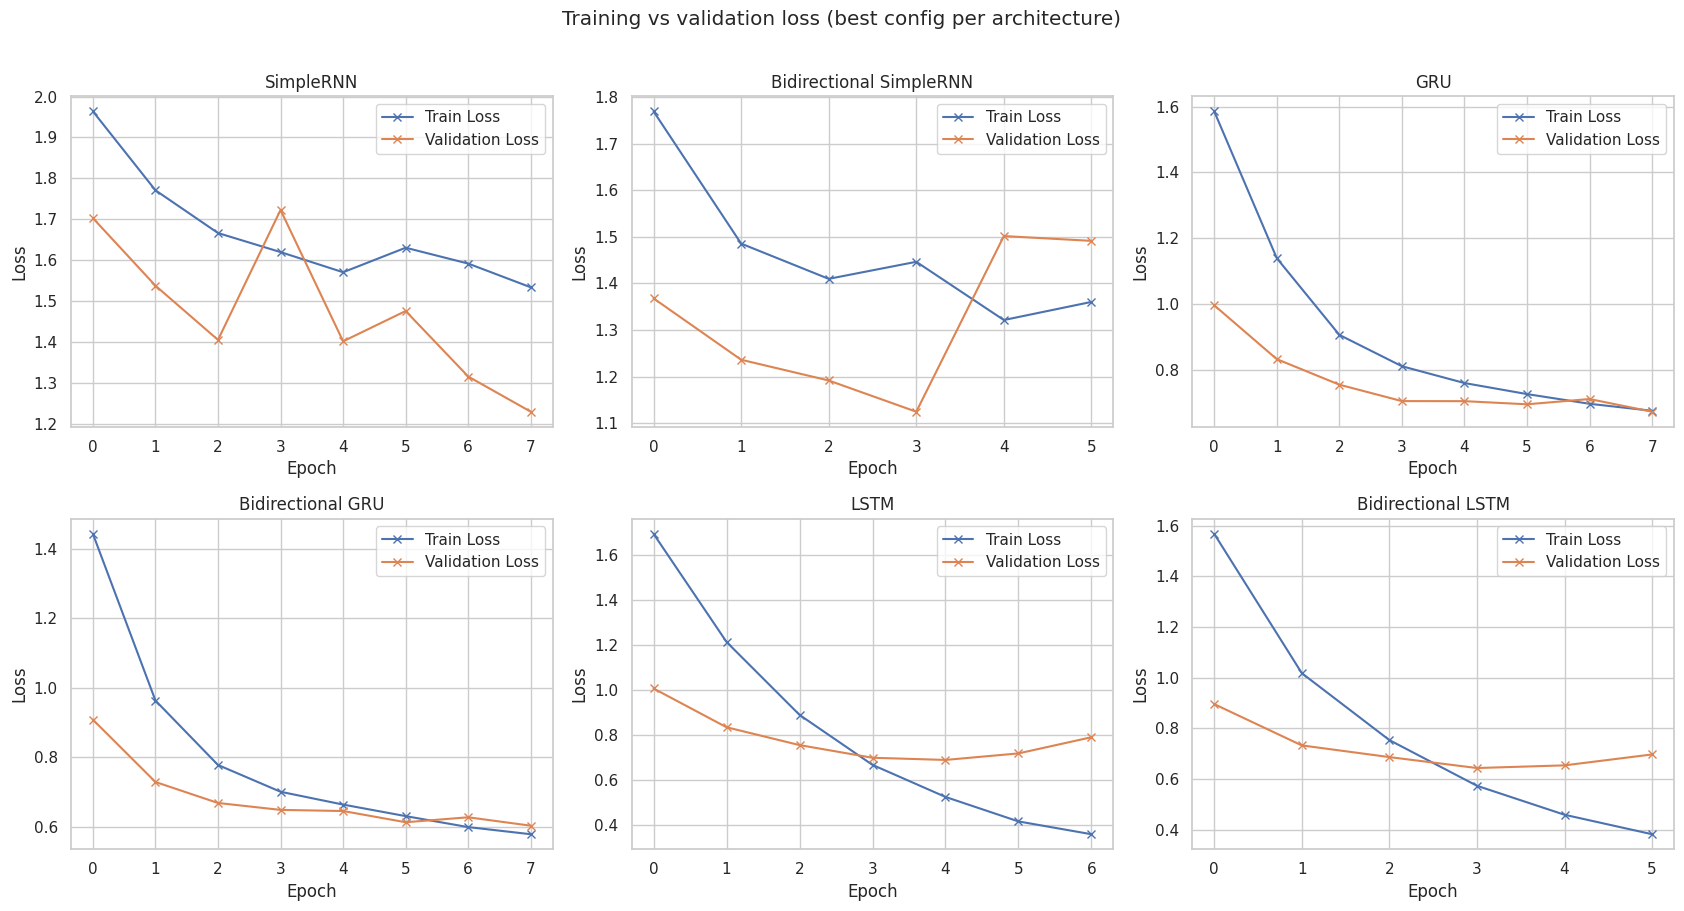

In [38]:
# Training curves for the best config per architecture (reloaded from nn_histories.json)
if nn_histories:
    n = len(nn_histories)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4.5 * nrows), squeeze=False)
    flat = axes.ravel()
    for ax, (name, h) in zip(flat, nn_histories.items()):
        ax.plot(h['loss'], marker='x', label='Train Loss')
        ax.plot(h['val_loss'], marker='x', label='Validation Loss')
        ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(); ax.grid(True)
    for ax in flat[n:]:
        ax.set_visible(False)
    plt.suptitle("Training vs validation loss (best config per architecture)", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("no neural-network histories recorded yet")

## 12. Screening chatbot

In [44]:
CRISIS_CLASSES = {"Suicidal"}
CONFIDENCE_FLOOR = 0.45

CRISIS_MESSAGE = (
    "It sounds like you may be going through something very painful right now, and I want to make sure "
    "you're getting real support rather than an automated label.\n\n"
    "Please reach out to a trained human:\n"
    "  - Bangladesh: Kaan Pete Roi emotional support helpline (kaanpeteroi.org for current hours/number)\n"
    "  - National Institute of Mental Health, Dhaka - emergency psychiatric services\n"
    "  - If you are in immediate danger, contact emergency services or go to the nearest hospital.\n\n"
    "You deserve support from someone who can actually be there with you."
)

DISCLAIMER = ("\n[Course project. Screening prototype trained on public forum text - "
              "not a diagnostic tool, and no substitute for a qualified clinician.]")

# Pick the strongest TF-IDF model that exposes calibrated-ish probabilities, straight from
# the saved artifacts - no hardcoded "Logistic Regression" to go stale.
PROBA_OK = {"Logistic Regression", "Naive Bayes"}
ranked_sklearn = [n for n in final_df["Model"]
                  if registry[n]["kind"] == "sklearn" and n in PROBA_OK]
CHATBOT_MODEL = ranked_sklearn[0] if ranked_sklearn else final_df["Model"].iloc[0]
chatbot_est = joblib.load(registry[CHATBOT_MODEL]["artifact"])
chatbot_vec = joblib.load(ART / "tfidf_vectorizer.joblib")
print("chatbot backend:", CHATBOT_MODEL)


def predict_proba_text(raw_text):
    cleaned = (preprocess(raw_text, "lemma") if TEXT_COL == "prep_lemma" else
               preprocess(raw_text, "stem")  if TEXT_COL == "prep_stem"  else
               basic_clean(raw_text))
    probs = chatbot_est.predict_proba(chatbot_vec.transform([cleaned]))[0]
    return dict(zip(le.inverse_transform(chatbot_est.classes_), probs))


def chatbot_respond(user_text):
    probs = predict_proba_text(user_text)
    top = max(probs, key=probs.get)
    conf = probs[top]

    # 1. Risk first: crisis routing overrides classification, even at moderate probability
    if any(probs.get(c, 0) >= 0.25 for c in CRISIS_CLASSES):
        return CRISIS_MESSAGE + DISCLAIMER

    # 2. Low confidence: elicit more, do not guess
    if conf < CONFIDENCE_FLOOR:
        return ("Thanks for sharing that. I don't have a clear enough picture yet - could you tell me more "
                "about how long you've been feeling this way, and how it's affecting your sleep, appetite, "
                "or daily routine?" + DISCLAIMER)

    # 3. Confident, non-crisis
    ranked = sorted(probs.items(), key=lambda kv: -kv[1])[:3]
    detail = ", ".join(f"{k}: {v:.0%}" for k, v in ranked)
    return (f"Based on what you wrote, the language pattern most resembles {top} ({conf:.0%} confidence).\n"
            f"Other possibilities considered - {detail}.\n\n"
            "This is a signal, not a diagnosis. If this matches how you've been feeling for more than two "
            "weeks, talking to a counsellor or GP is a reasonable next step." + DISCLAIMER)


for t in ["i have been feeling low and empty for weeks, nothing interests me anymore",
          "just finished my assignment and going out with friends tonight",
          "my heart races every time i have to speak in class and i cannot breathe properly",
          "I am getting numb due to the pain inflicted by someone. I don't feel any interest in anything. I have been feeling low and empty for weeks, nothing interests me anymore"]:
    print(">>", t)
    print(chatbot_respond(t))
    print("-" * 80)

chatbot backend: Logistic Regression
>> i have been feeling low and empty for weeks, nothing interests me anymore
Based on what you wrote, the language pattern most resembles Depression (50% confidence).
Other possibilities considered - Depression: 50%, Suicidal: 20%, Normal: 16%.

This is a signal, not a diagnosis. If this matches how you've been feeling for more than two weeks, talking to a counsellor or GP is a reasonable next step.
[Course project. Screening prototype trained on public forum text - not a diagnostic tool, and no substitute for a qualified clinician.]
--------------------------------------------------------------------------------
>> just finished my assignment and going out with friends tonight
Based on what you wrote, the language pattern most resembles Normal (70% confidence).
Other possibilities considered - Normal: 70%, Stress: 9%, Depression: 9%.

This is a signal, not a diagnosis. If this matches how you've been feeling for more than two weeks, talking to a co

## 13. Artifact completeness check

In [40]:
# Fail loudly if this version's output is NOT a complete, hostable set.
EXPECTED = list(model_configs) + list(rnn_layers) + (["BERT Base"] if BERT_OK else [])
SUPPORT  = ["meta.json", "registry.json", "label_encoder.joblib",
            "tfidf_vectorizer.joblib", "keras_tokenizer.json",
            "emb_word2vec.npy", "emb_glove.npy"]

rows, missing = [], []
for name in EXPECTED:
    entry = registry.get(name)
    if entry is None:
        rows.append({"model": name, "status": "MISSING from registry", "MB": 0.0})
        missing.append(name)
        continue
    p = Path(entry["artifact"])
    if p.is_dir():
        size = sum(f.stat().st_size for f in p.rglob("*") if f.is_file())
    elif p.exists():
        size = p.stat().st_size
    else:
        size = 0
    ok = size > 0
    if not ok:
        missing.append(name)
    rows.append({"model": name,
                 "status": "ok" if ok else "FILE NOT FOUND",
                 "val_macro_f1": entry["val_macro_f1"],
                 "MB": round(size / 1e6, 2),
                 "path": entry["artifact"]})

display(pd.DataFrame(rows))

missing_support = [f for f in SUPPORT if not (ART / f).exists()]
total_mb = sum(f.stat().st_size for f in ART.rglob("*") if f.is_file()) / 1e6
print(f"\ntotal artifact size: {total_mb:.1f} MB")

if missing or missing_support:
    print("\n*** INCOMPLETE ***")
    if missing:         print("  models missing weights:", missing)
    if missing_support: print("  support files missing:", missing_support)
    print("  Do NOT treat this version as the hostable one. Attach the previous version's")
    print("  output as an input (see section 1) and re-run so the gaps are filled in.")
else:
    print("\nAll models present. This version's output is a complete, downloadable set.")

,model,status,val_macro_f1,MB,path
0,Logistic Regression,ok,0.7307,1.08,/kaggle/working/artifacts/logistic_regression....
1,Random Forest,ok,0.6453,103.27,/kaggle/working/artifacts/random_forest.joblib
2,Naive Bayes,ok,0.6102,2.15,/kaggle/working/artifacts/naive_bayes.joblib
3,SimpleRNN,ok,0.3476,46.03,/kaggle/working/artifacts/simplernn.keras
4,Bidirectional SimpleRNN,ok,0.4436,51.45,/kaggle/working/artifacts/bidirectional_simple...
5,GRU,ok,0.6895,51.52,/kaggle/working/artifacts/gru.keras
6,Bidirectional GRU,ok,0.7270,51.96,/kaggle/working/artifacts/bidirectional_gru.keras
7,LSTM,ok,0.6966,63.36,/kaggle/working/artifacts/lstm.keras
8,Bidirectional LSTM,ok,0.7189,64.88,/kaggle/working/artifacts/bidirectional_lstm.k...
9,BERT Base,ok,0.7922,438.69,/kaggle/working/artifacts/bert_base



total artifact size: 918.4 MB

All models present. This version's output is a complete, downloadable set.


## 14. Reusing the saved artifacts

`/kaggle/working/artifacts/` now contains everything needed to reproduce inference without
retraining:

| file | what it is |
|---|---|
| `registry.json` | which model won each architecture, its val score, and where its weights live |
| `meta.json` | `TEXT_COL`, `max_len`, `VOCAB_SIZE`, `EMB_DIM`, class names |
| `label_encoder.joblib`, `splits.npz` | label mapping and the exact train/val/test indices |
| `tfidf_vectorizer.joblib`, `keras_tokenizer.json` | the two fitted text encoders |
| `logistic_regression.joblib`, `random_forest.joblib`, `naive_bayes.joblib` | sklearn winners |
| `simplernn.keras`, `gru.keras`, `lstm.keras`, `bidirectional_*.keras` | Keras winners |
| `bert_base/` | fine-tuned BERT (`save_pretrained` format) |
| `emb_word2vec.npy`, `emb_glove.npy`, `word2vec.model` | embedding matrices and the trained Word2Vec |
| `hyperparameter_tuning_log.csv`, `final_model_comparison.csv`, `nn_histories.json` | results for the report |

To load one later:

```python
import joblib, json, tensorflow as tf
from pathlib import Path

ART = Path("/kaggle/working/artifacts")
registry = json.loads((ART / "registry.json").read_text())

clf = joblib.load(registry["Logistic Regression"]["artifact"])   # sklearn
rnn = tf.keras.models.load_model(registry["LSTM"]["artifact"])   # keras
```

To keep them across sessions, run **Save Version > Save & Run All**, then attach the
finished kernel's output as a dataset input to your next notebook.

With `RESUME = True` at the top, re-running this notebook skips every model already in
`registry.json` - so an interrupted run picks up where it stopped. To force one model to
retrain, delete its entry from `registry.json`; to retrain everything, set `RESUME = False`.

### Version workflow for hosting

1. **First run** - train interactively (GPU on, Internet on). If it times out, just run the
   remaining cells again; `RESUME` skips whatever already finished.
2. **Save Version -> Quick Save** once section 13 reports a complete set. Quick Save keeps
   the files already in `/kaggle/working` without re-running anything.
3. **Add Input -> Notebook Output -> this notebook -> latest version.** Do this once.
4. **Every later version** now inherits all previous weights via the carry-forward cell, so
   the newest version's output is always the full set - even if that run only retrained one
   model.
5. **To download:** open the notebook's **Output** tab on the latest version and use
   *Download All*, or grab individual files. For programmatic access:
   `kaggle kernels output <user>/<notebook-slug> -p ./weights`.

To serve the model outside Kaggle you need, at minimum: the winning model file, plus
`tfidf_vectorizer.joblib` (sklearn) or `keras_tokenizer.json` + `meta.json` (Keras), plus
`label_encoder.joblib` to map predictions back to class names.